# Exploratory Data Analysis (EDA) on CelebA Dataset
**BTL Machine Learning — Computer Vision Module**

This notebook demonstrates an end-to-end Exploratory Data Analysis (EDA) of the **CelebA (CelebFaces Attributes)** dataset using the modular toolkit in `modules/vision/eda/`.

### Coverage across all vision EDA modules
1. **Environment Setup & Imports**: Initializing paths and libraries.
2. **Dataset Partitions Analysis (`modules.vision.eda.labels`)**: Train / Validation / Test split balance and overlap checks.
3. **Image Exploration & Quality Analysis (`modules.vision.eda.images`)**: Dimensions, aspect ratios, file sizes, RGB channels, and luminance distributions.
4. **Facial Landmarks Analysis (`modules.vision.eda.landmarks`)**: Five facial keypoints (eyes, nose, mouth corners) distributions and image overlays.
5. **Face Bounding Box Analysis (`modules.vision.eda.eval`)**: Bounding box coordinate ranges, box aspect ratios, areas, anomaly detection, and overlays on raw images.
6. **Facial Attributes & Evaluation Labels Analysis (`modules.vision.eda.eval`)**: 40 binary facial attributes, class imbalance, split stability, correlations, and image overlays.
7. **Base EDA Module Interface (`modules.vision.eda.base`)**: Verification of base runner.
8. **Summary of Findings & Recommendations**: Core takeaways for downstream modeling.

In [1]:
import sys
from pathlib import Path

# Locate project root dynamically (supports running from notebooks/ or workspace root)
cwd = Path.cwd().resolve()
if (cwd / "modules").is_dir():
    project_root = cwd
elif (cwd.parent / "modules").is_dir():
    project_root = cwd.parent
else:
    project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Dataset paths
data_dir = project_root / "data"
align_img_dir = data_dir / "img_align_celeba"
raw_img_dir = data_dir / "img_celeba"

partition_path = data_dir / "list_eval_partition.csv"
landmark_path = data_dir / "list_landmarks_align_celeba.csv"
bbox_path = data_dir / "list_bbox_celeba.csv"
attr_path = data_dir / "list_attr_celeba.csv"

print(f"Project root: {project_root}")
print(f"Data directory: {data_dir}")
all_exist = all(p.exists() for p in [partition_path, landmark_path, bbox_path, attr_path, align_img_dir, raw_img_dir])
print(f"All expected files and directories exist: {all_exist}")

Project root: /home/triefeu/Documents/BTL-Machine-learning
Data directory: /home/triefeu/Documents/BTL-Machine-learning/data
All expected files and directories exist: True


## 1. Dataset Partitions EDA (`modules.vision.eda.labels`)
CelebA designates standardized evaluation splits:
- `0`: Training set (~162,770 images, ~80%)
- `1`: Validation set (~19,867 images, ~10%)
- `2`: Testing set (~19,962 images, ~10%)

We load, validate for leaks, summarize, and plot the partition distribution.

In [2]:
from modules.vision.eda.labels import (
    load_partitions,
    check_partitions,
    summarize_partitions,
    plot_partition_counts,
)

# 1. Load partition table
df_partitions = load_partitions(partition_path)
print(f"Loaded {len(df_partitions):,} partition entries.")
df_partitions.head()

Loaded 202,599 partition entries.


,image_id,partition
0,000001.jpg,0
1,000002.jpg,0
2,000003.jpg,0
3,000004.jpg,0
4,000005.jpg,0


In [3]:
# 2. Integrity and overlap checks
partition_check = check_partitions(df_partitions)
print("Partition Validation Results:")
for k, v in partition_check.items():
    print(f"  {k}: {v}")

Partition Validation Results:
  total_rows: 202599
  missing_image_ids: 0
  missing_partitions: 0
  invalid_partitions: 0
  duplicate_image_ids: 0
  train_validation_overlap: 0
  train_test_overlap: 0
  validation_test_overlap: 0


In [4]:
# 3. Statistical summary of splits
summary_partitions = summarize_partitions(df_partitions)
summary_partitions

,count,percent
split,,
train,162770,80.340969
validation,19867,9.806070
test,19962,9.852961


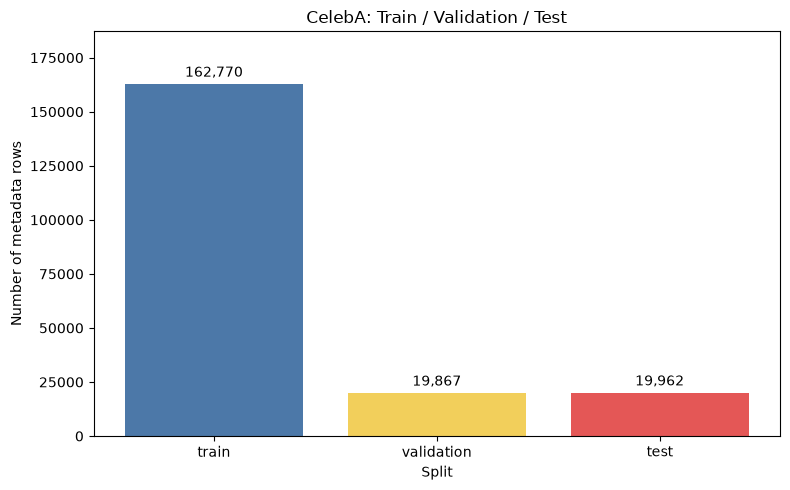

In [5]:
# 4. Plot partition distribution
ax = plot_partition_counts(df_partitions)
plt.show()

## 2. Image Metadata & Quality EDA (`modules.vision.eda.images`)
CelebA provides aligned face crops in `img_align_celeba` and unaligned raw images in `img_celeba`.
Here we inspect image properties (file sizes, resolutions, aspect ratios, RGB brightness) on a sample of training images using `scan_images`.

In [6]:
from modules.vision.eda.images import (
    scan_images,
    check_images,
    summarize_images,
    plot_image_distributions,
    plot_sample_images,
)

# Sample training images to scan efficiently without full disk traversal
sample_train_ids = df_partitions.loc[df_partitions["partition"] == 0, "image_id"].head(500).tolist()
df_images = scan_images(align_img_dir, image_ids=sample_train_ids)
print(f"Scanned {len(df_images)} images.")
df_images.head()

Scanned 500 images.


,image_id,mode,width,height,aspect_ratio,file_size_kb,red_mean,green_mean,blue_mean,brightness_mean,brightness_std,error
0,000001.jpg,RGB,178.0,218.0,0.816514,11.171875,0.709914,0.537462,0.430295,0.576808,0.297545,None
1,000002.jpg,RGB,178.0,218.0,0.816514,7.273438,0.516219,0.442556,0.421383,0.462168,0.230857,None
2,000003.jpg,RGB,178.0,218.0,0.816514,4.153320,0.577920,0.527974,0.496466,0.539316,0.216834,None
3,000004.jpg,RGB,178.0,218.0,0.816514,10.495117,0.351573,0.258238,0.196637,0.279123,0.275394,None
4,000005.jpg,RGB,178.0,218.0,0.816514,6.202148,0.638501,0.627608,0.594858,0.627131,0.224722,None


In [7]:
# Integrity check: color mode, readability, dimensional consistency
image_check = check_images(df_images)
print("Image Integrity Check:")
for k, v in image_check.items():
    print(f"  {k}: {v}")

Image Integrity Check:
  total_images: 500
  readable_images: 500
  unreadable_images: 0
  non_rgb_images: 0
  distinct_dimensions: 1


In [8]:
# Statistical summary of image metrics
summarize_images(df_images)

,count,mean,std,min,25%,50%,75%,max
metric,,,,,,,,
width,500.0,178.000000,0.000000,178.000000,178.000000,178.000000,178.000000,178.000000
height,500.0,218.000000,0.000000,218.000000,218.000000,218.000000,218.000000,218.000000
aspect_ratio,500.0,0.816514,0.000000,0.816514,0.816514,0.816514,0.816514,0.816514
file_size_kb,500.0,6.865109,1.250801,3.961914,6.019043,6.684570,7.609131,11.958008
red_mean,500.0,0.516043,0.151419,0.178091,0.396452,0.520573,0.625477,0.893791
green_mean,500.0,0.434087,0.146097,0.104620,0.322875,0.431372,0.544513,0.819780
blue_mean,500.0,0.390011,0.149200,0.054012,0.267375,0.383587,0.503860,0.800764
brightness_mean,500.0,0.453567,0.144792,0.120819,0.342676,0.449853,0.563222,0.827402
brightness_std,500.0,0.246836,0.049205,0.091998,0.213048,0.245141,0.278303,0.396803


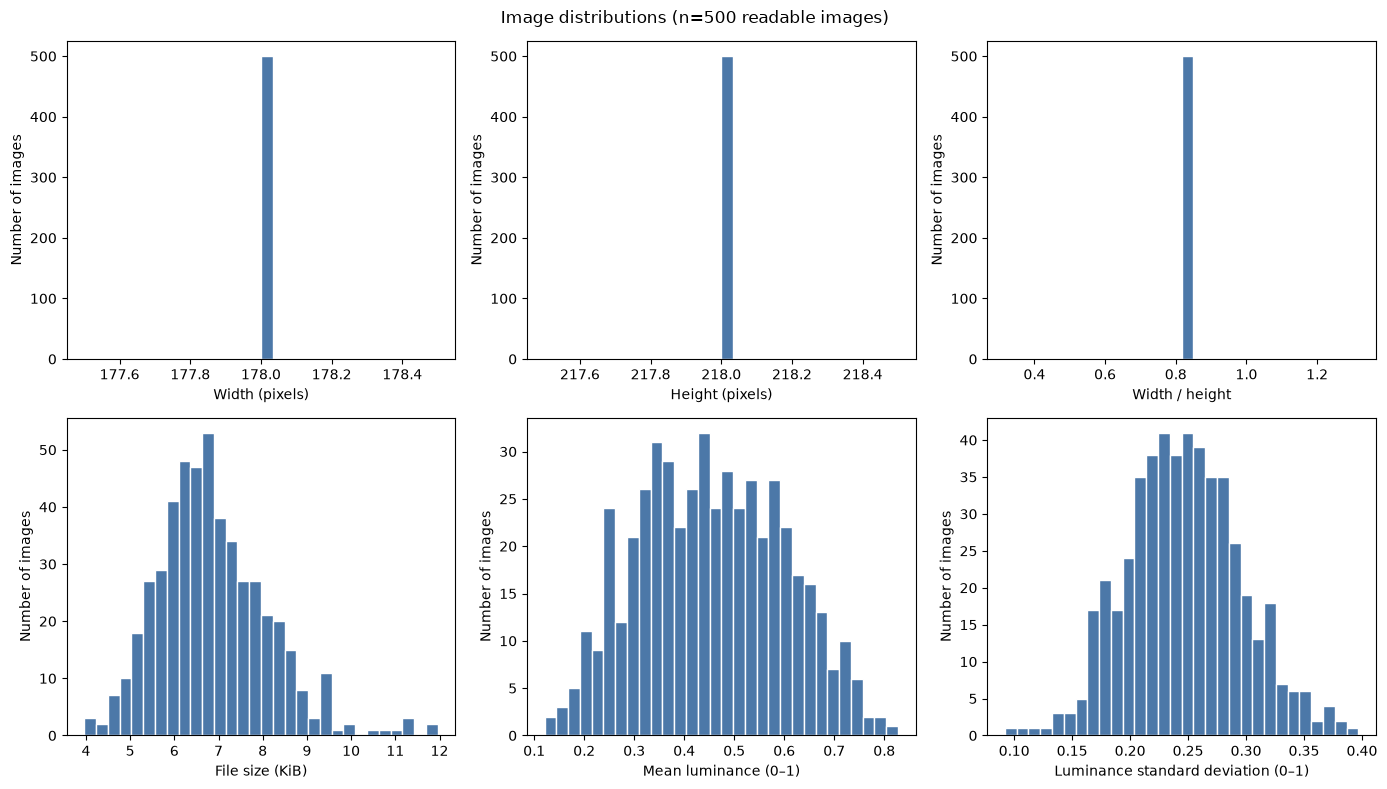

In [9]:
# Distribution histograms of image dimensions, size, and luminance
fig_img_dist = plot_image_distributions(df_images)
plt.show()

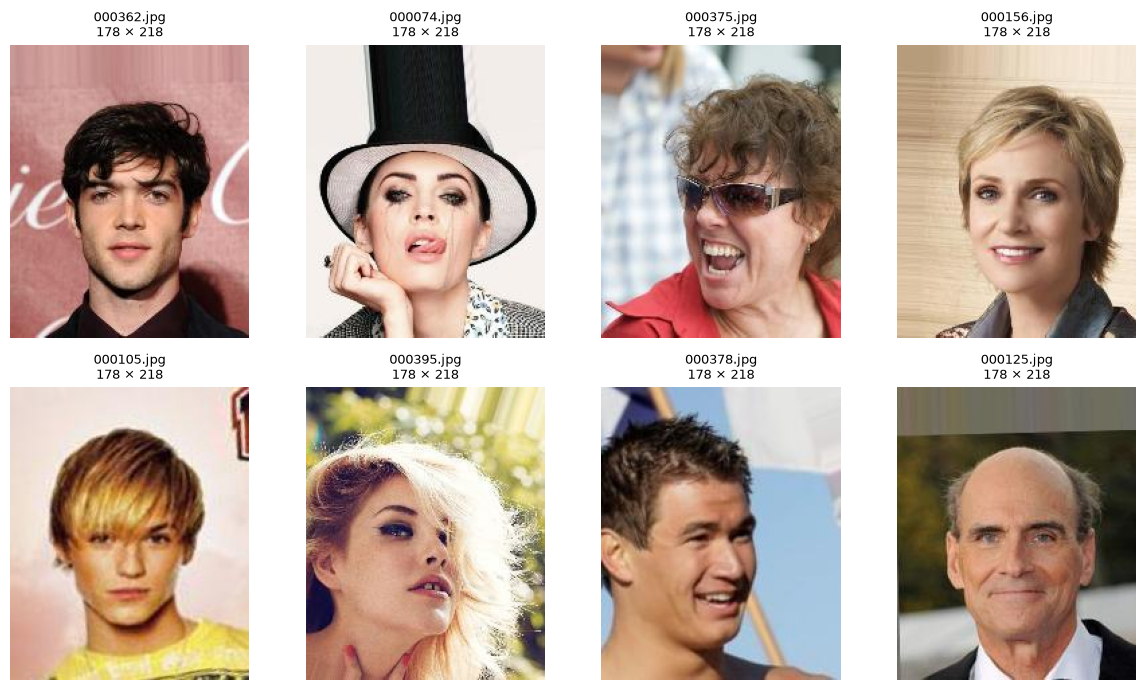

In [10]:
# Gallery of readable images
fig_img_samples = plot_sample_images(df_images, align_img_dir, n_images=8, random_state=42)
plt.show()

## 3. Facial Landmarks EDA (`modules.vision.eda.landmarks`)
CelebA provides five key facial landmarks per image:
- Left eye (`lefteye_x`, `lefteye_y`)
- Right eye (`righteye_x`, `righteye_y`)
- Nose (`nose_x`, `nose_y`)
- Left mouth corner (`leftmouth_x`, `leftmouth_y`)
- Right mouth corner (`rightmouth_x`, `rightmouth_y`)

These annotations align with `img_align_celeba`.

In [11]:
from modules.vision.eda.landmarks import (
    load_landmarks,
    check_landmarks,
    summarize_landmarks,
    plot_landmarks_on_images,
    plot_landmark_distribution,
)

# Load facial landmarks
df_landmarks = load_landmarks(landmark_path)
print(f"Loaded landmarks for {len(df_landmarks):,} images.")
df_landmarks.head()

Loaded landmarks for 202,599 images.


,image_id,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,69,109,106,113,77,142,73,152,108,154
1,000002.jpg,69,110,107,112,81,135,70,151,108,153
2,000003.jpg,76,112,104,106,108,128,74,156,98,158
3,000004.jpg,72,113,108,108,101,138,71,155,101,151
4,000005.jpg,66,114,112,112,86,119,71,147,104,150


In [12]:
# Validate landmarks against partitions
landmark_check = check_landmarks(df_landmarks, partitions=df_partitions)
print("Landmark Validation Results:")
for k, v in landmark_check.items():
    print(f"  {k}: {v}")

Landmark Validation Results:
  total_rows: 202599
  missing_image_ids: 0
  duplicate_image_ids: 0
  missing_coordinate_values: 0
  invalid_coordinate_values: 0
  rows_with_coordinate_issues: 0
  negative_coordinate_values: 0
  landmark_ids_without_partition: 0
  partition_ids_without_landmarks: 0


In [13]:
# Descriptive statistics across all 10 landmark coordinates
summarize_landmarks(df_landmarks)

,count,mean,std,min,25%,50%,75%,max
coordinate,,,,,,,,
lefteye_x,202599.0,69.353867,1.717952,56.0,68.0,69.0,70.0,88.0
lefteye_y,202599.0,111.197982,1.129284,98.0,111.0,111.0,112.0,129.0
righteye_x,202599.0,107.644031,1.690252,90.0,107.0,108.0,109.0,124.0
righteye_y,202599.0,111.161600,1.169229,95.0,111.0,111.0,112.0,122.0
nose_x,202599.0,88.063140,6.647733,57.0,84.0,88.0,92.0,121.0
nose_y,202599.0,135.102024,4.245078,93.0,133.0,135.0,138.0,156.0
leftmouth_x,202599.0,71.247459,3.168011,57.0,69.0,72.0,73.0,90.0
leftmouth_y,202599.0,152.113011,1.799343,116.0,151.0,152.0,153.0,174.0
rightmouth_x,202599.0,105.586429,3.233125,82.0,103.0,105.0,108.0,120.0


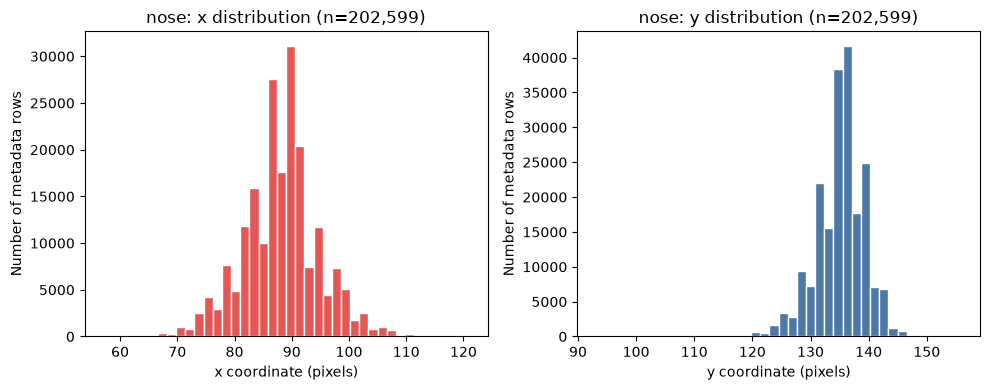

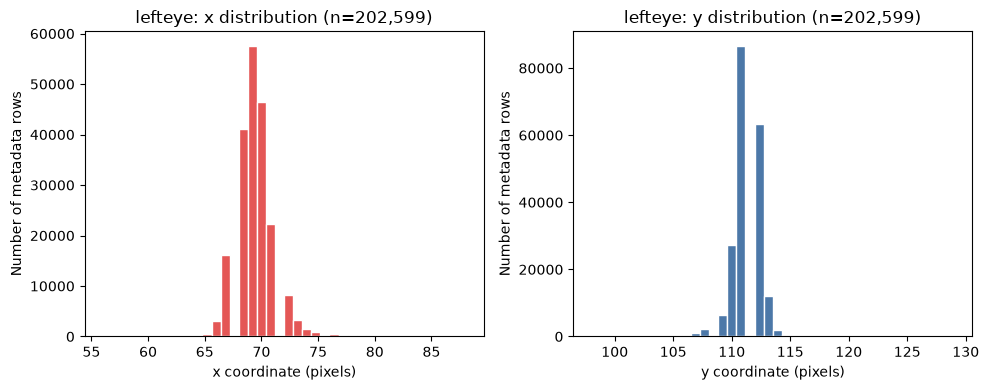

In [14]:
# Histograms for Nose and Left Eye coordinate distributions
fig_nose = plot_landmark_distribution(df_landmarks, landmark="nose", bins=40)
plt.show()

fig_eye = plot_landmark_distribution(df_landmarks, landmark="lefteye", bins=40)
plt.show()

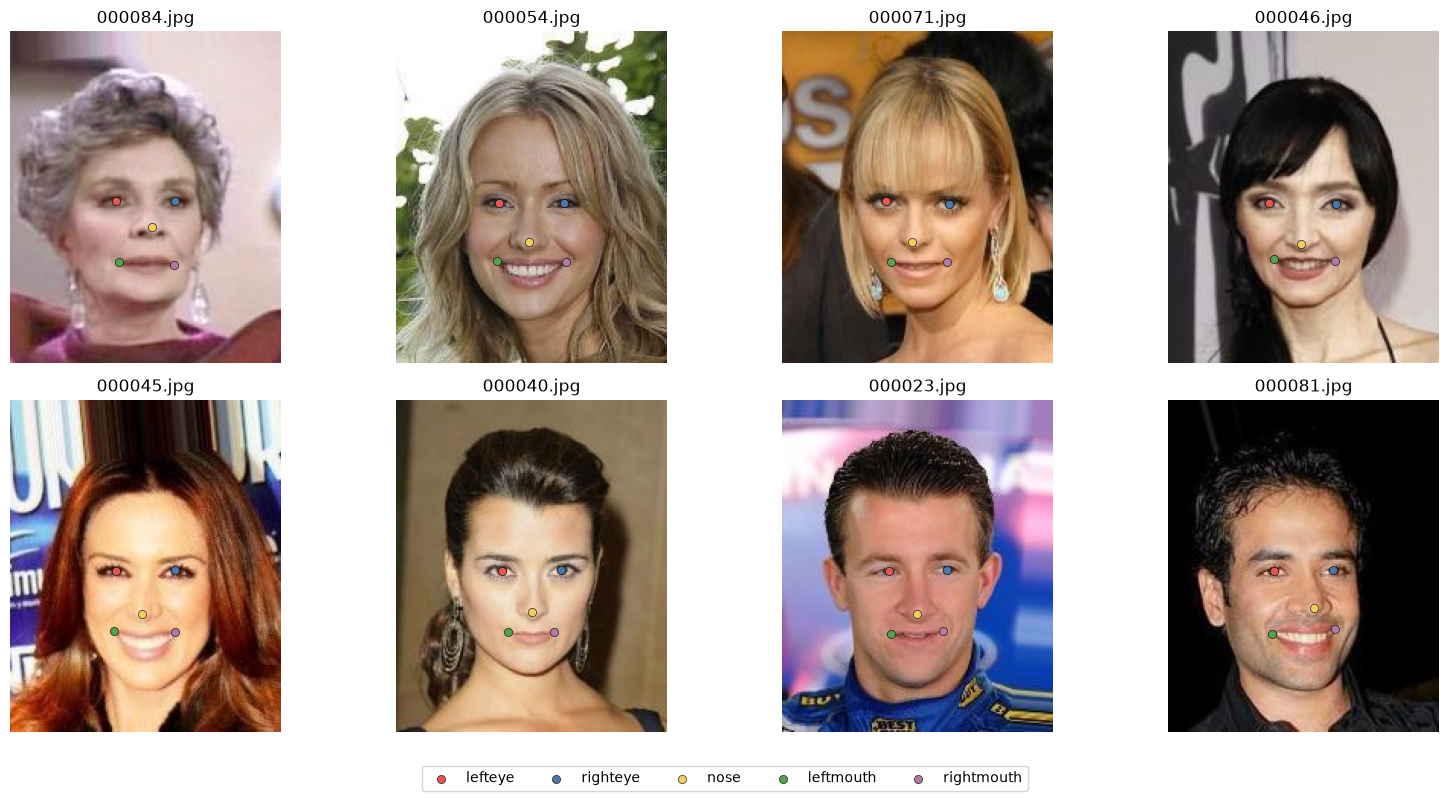

In [15]:
# Overlay landmarks onto aligned images
fig_landmarks_samples = plot_landmarks_on_images(
    df_landmarks.head(100),
    align_img_dir,
    n_images=8,
    random_state=42,
)
plt.show()

## 4. Face Bounding Box EDA (`modules.vision.eda.eval`)
Face bounding boxes (`x_1`, `y_1`, `width`, `height`) correspond to the unaligned, raw CelebA images in `img_celeba`.
We inspect coordinates, aspect ratios ($W/H$), areas, detect anomalous degenerate boxes, and overlay bounding boxes onto raw images.

In [16]:
from modules.vision.eda.eval import (
    load_bboxes,
    check_bboxes,
    summarize_bboxes,
    plot_bboxes_on_images,
    plot_bbox_distributions,
)

# Load bounding box annotations
df_bboxes = load_bboxes(bbox_path)
print(f"Loaded {len(df_bboxes):,} bounding boxes.")
df_bboxes.head()

Loaded 202,599 bounding boxes.


,image_id,x_1,y_1,width,height
0,000001.jpg,95,71,226,313
1,000002.jpg,72,94,221,306
2,000003.jpg,216,59,91,126
3,000004.jpg,622,257,564,781
4,000005.jpg,236,109,120,166


In [17]:
# Validate bounding box data consistency and check for degenerate annotations
bbox_check = check_bboxes(df_bboxes, partitions=df_partitions)
print("Bounding Box Validation Results:")
for k, v in bbox_check.items():
    print(f"  {k}: {v}")

Bounding Box Validation Results:
  total_rows: 202599
  missing_image_ids: 0
  duplicate_image_ids: 0
  missing_coordinate_values: 0
  invalid_coordinate_values: 0
  negative_coordinate_values: 0
  non_positive_dimension_values: 1
  rows_with_bbox_issues: 1
  bbox_ids_without_partition: 0
  partition_ids_without_bbox: 0


In [18]:
# Summary statistics for coordinates, dimensions, aspect ratio, and area
summary_bboxes = summarize_bboxes(df_bboxes)
summary_bboxes

,count,mean,std,min,25%,50%,75%,max
metric,,,,,,,,
x_1,202599.0,156.764564,164.518135,1.000000,69.000000,110.000000,181.000000,3840.00
y_1,202599.0,84.335505,76.067284,0.000000,44.000000,68.000000,98.000000,1858.00
width,202599.0,194.754061,141.770066,0.000000,120.000000,164.000000,221.000000,3827.00
height,202599.0,268.922329,195.664936,0.000000,166.000000,227.000000,306.000000,5299.00
aspect_ratio,202598.0,0.724000,0.021138,0.350453,0.721925,0.722222,0.722543,1.75
area,202598.0,80080.281597,223229.237902,12.000000,19920.000000,37228.000000,67626.000000,20279273.00


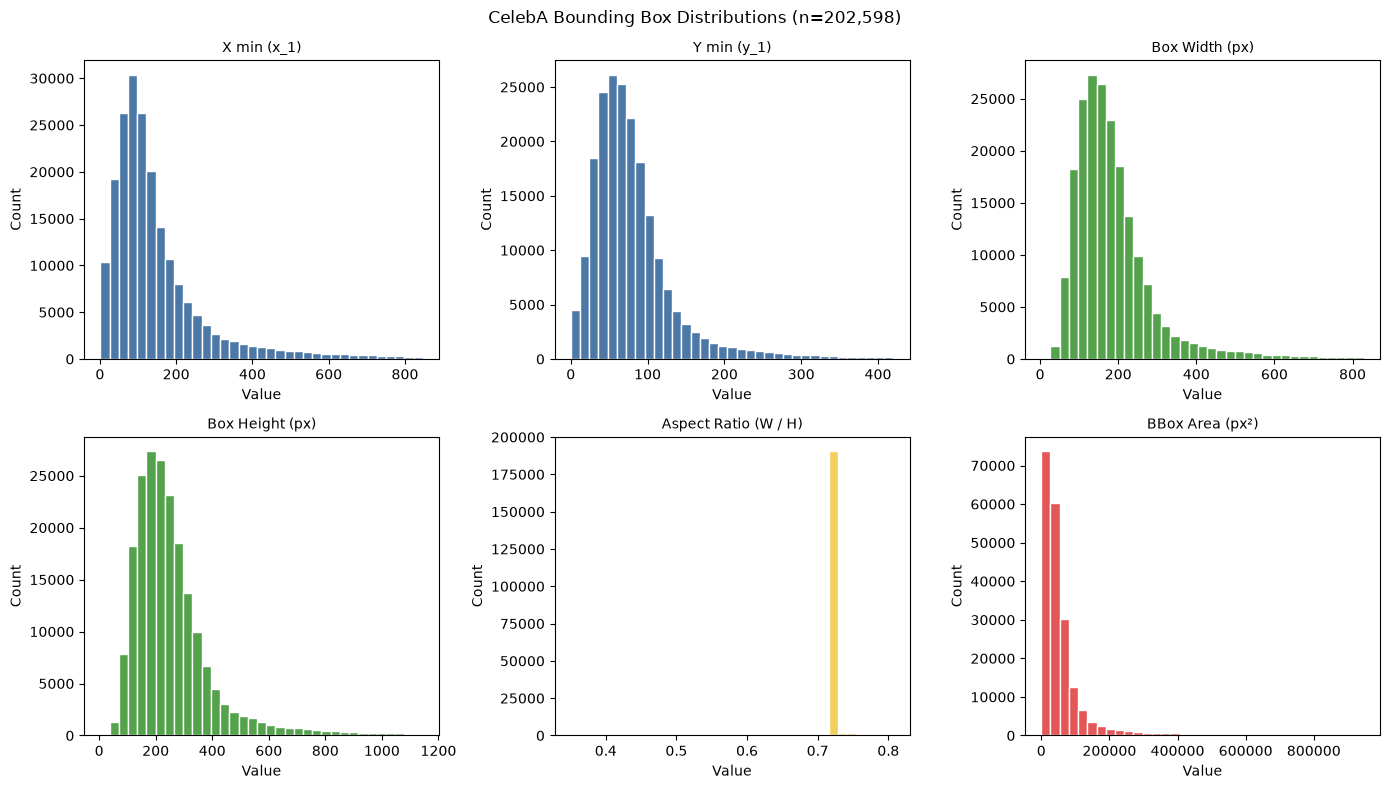

In [19]:
# Histograms of bounding box dimensions, aspect ratio, and area
fig_bbox_dist = plot_bbox_distributions(df_bboxes)
plt.show()

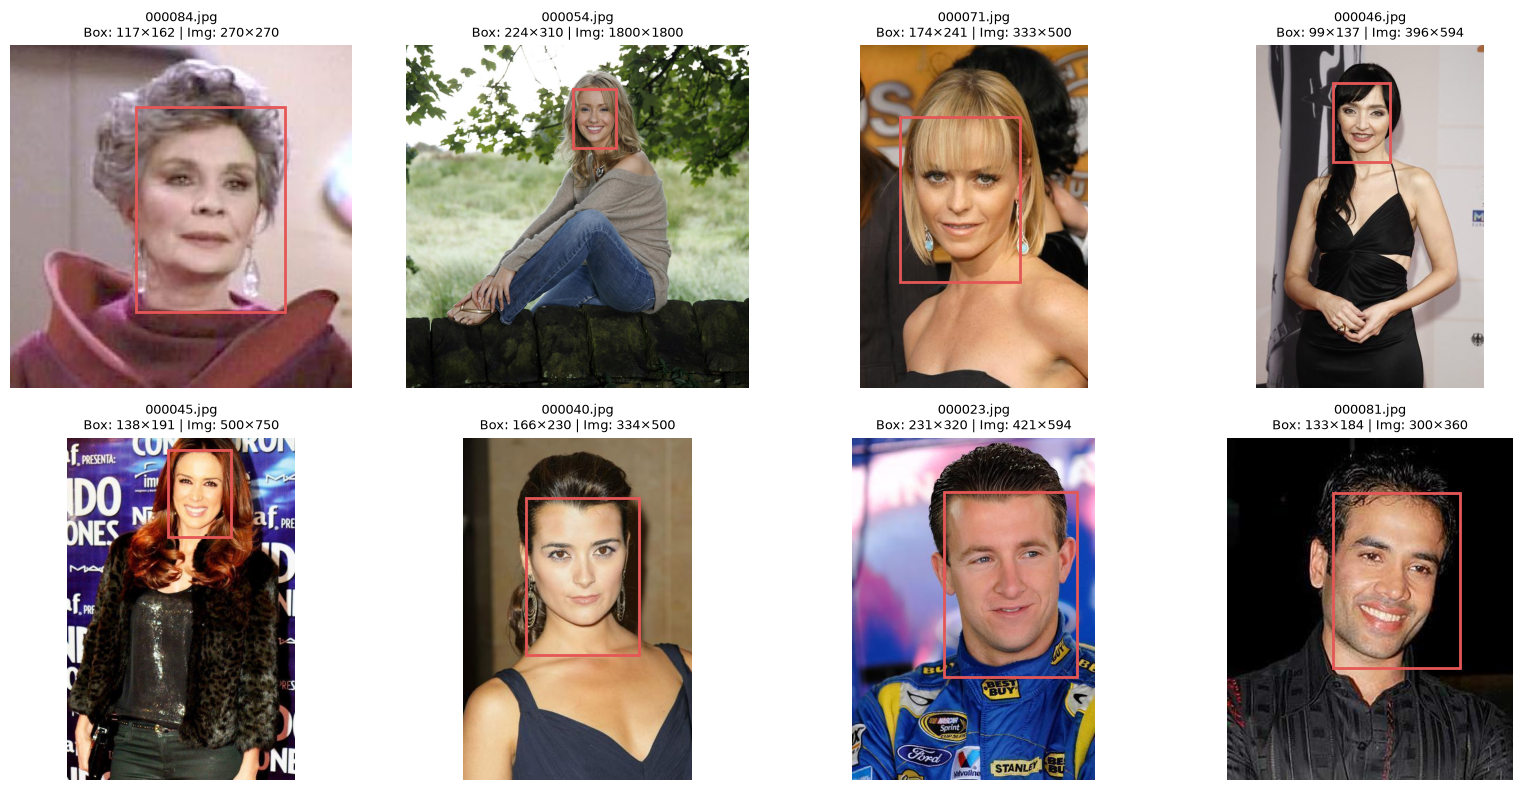

In [20]:
# Overlay bounding boxes onto raw unaligned images
fig_bboxes_samples = plot_bboxes_on_images(
    df_bboxes.head(100),
    raw_img_dir,
    n_images=8,
    random_state=42,
)
plt.show()

## 5. Facial Attributes & Evaluation Labels EDA (`modules.vision.eda.eval`)
CelebA annotates 40 binary facial attributes per image (-1 = Absent, 1 = Present).
In this section, we analyze:
1. **Label Validity & Missingness**: Checking binary encoding {-1, 1}.
2. **Class Imbalance**: Positive prevalence and majority-to-minority ratios.
3. **Partition Stability**: Distribution consistency across train, val, and test splits.
4. **Correlation Structure**: Pearson correlations between key facial attributes.
5. **Sample Gallery**: Displaying active positive attributes for sample faces.

In [21]:
from modules.vision.eda.eval import (
    load_attributes,
    check_attributes,
    summarize_attributes,
    summarize_attribute_partitions,
    plot_attribute_imbalance,
    plot_attribute_correlations,
    plot_sample_attributes,
)

# Load facial attribute labels
df_attributes = load_attributes(attr_path)
print(f"Loaded {len(df_attributes):,} rows with {df_attributes.shape[1] - 1} attributes.")
df_attributes.head()

Loaded 202,599 rows with 40 attributes.


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


In [22]:
# Validate attribute values and verify zero missingness
attr_check = check_attributes(df_attributes, partitions=df_partitions)
print("Attribute Validation Results:")
for k, v in attr_check.items():
    print(f"  {k}: {v}")

Attribute Validation Results:
  total_rows: 202599
  total_attributes: 40
  missing_image_ids: 0
  duplicate_image_ids: 0
  missing_attribute_values: 0
  invalid_numeric_values: 0
  non_binary_values: 0
  rows_with_attribute_issues: 0
  attr_ids_without_partition: 0
  partition_ids_without_attr: 0


In [23]:
# Summarize class frequencies and imbalance ratios
summary_attrs = summarize_attributes(df_attributes)

print("Top 5 Rarest / Most Imbalanced Attributes:")
print(summary_attrs.head(5)[["positive_count", "positive_pct", "imbalance_ratio"]])

print("\nTop 5 Most Common Attributes:")
print(summary_attrs.tail(5)[["positive_count", "positive_pct", "imbalance_ratio"]])

Top 5 Rarest / Most Imbalanced Attributes:
             positive_count  positive_pct  imbalance_ratio
attribute                                                 
Bald                   4547      2.244335        43.556631
Mustache               8417      4.154512        23.070215
Gray_Hair              8499      4.194986        22.837981
Pale_Skin              8701      4.294690        22.284565
Double_Chin            9459      4.668829        20.418649

Top 5 Most Common Attributes:
                     positive_count  positive_pct  imbalance_ratio
attribute                                                         
Smiling                       97669     48.208037         1.074343
Mouth_Slightly_Open           97942     48.342786         1.068561
Attractive                   103833     51.250500         1.051303
Young                        156734     77.361685         3.417290
No_Beard                     169158     83.493996         5.058401


In [24]:
# Compare attribute prevalence across Train, Validation, and Test splits
split_attr_summary = summarize_attribute_partitions(df_attributes, df_partitions)
print("Attributes with largest split percentage difference:")
split_attr_summary.head(10)

Attributes with largest split percentage difference:


,train_pos_pct,val_pos_pct,test_pos_pct,max_split_diff
attribute,,,,
Big_Lips,24.091049,15.321891,32.702134,17.380243
Wavy_Hair,31.935860,27.658932,36.404168,8.745236
Wearing_Lipstick,46.960128,44.596567,52.189159,7.592592
Narrow_Eyes,11.592431,7.509941,14.868250,7.358309
Black_Hair,23.902439,20.858710,27.161607,6.302897
Brown_Hair,20.391964,24.125434,17.969141,6.156293
Male,41.937089,42.573111,38.648432,3.924679
Big_Nose,23.555323,24.880455,21.200281,3.680174
High_Cheekbones,45.244824,44.928776,48.181545,3.252769


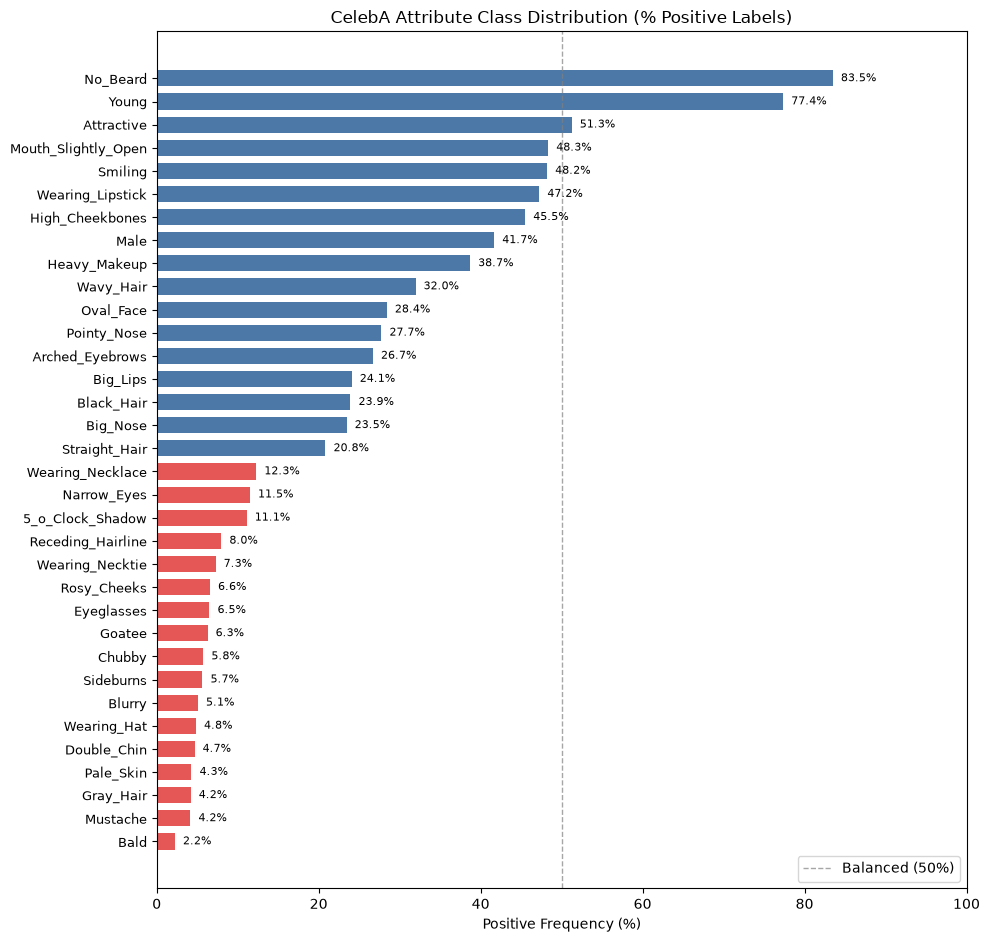

In [25]:
# Plot attribute class balance
fig_attr_imb = plot_attribute_imbalance(df_attributes, top_n=35)
plt.show()

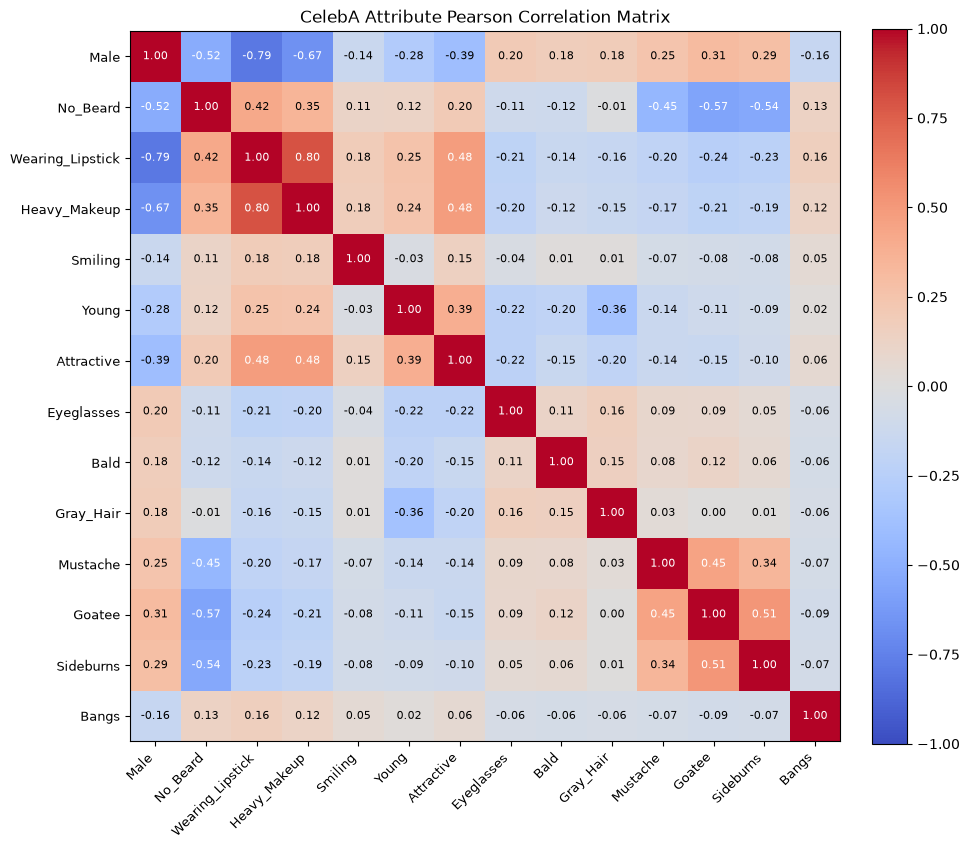

In [26]:
# Correlation heatmap between key attributes
fig_attr_corr = plot_attribute_correlations(
    df_attributes,
    attributes=[
        "Male", "No_Beard", "Wearing_Lipstick", "Heavy_Makeup",
        "Smiling", "Young", "Attractive", "Eyeglasses", "Bald",
        "Gray_Hair", "Mustache", "Goatee", "Sideburns", "Bangs"
    ]
)
plt.show()

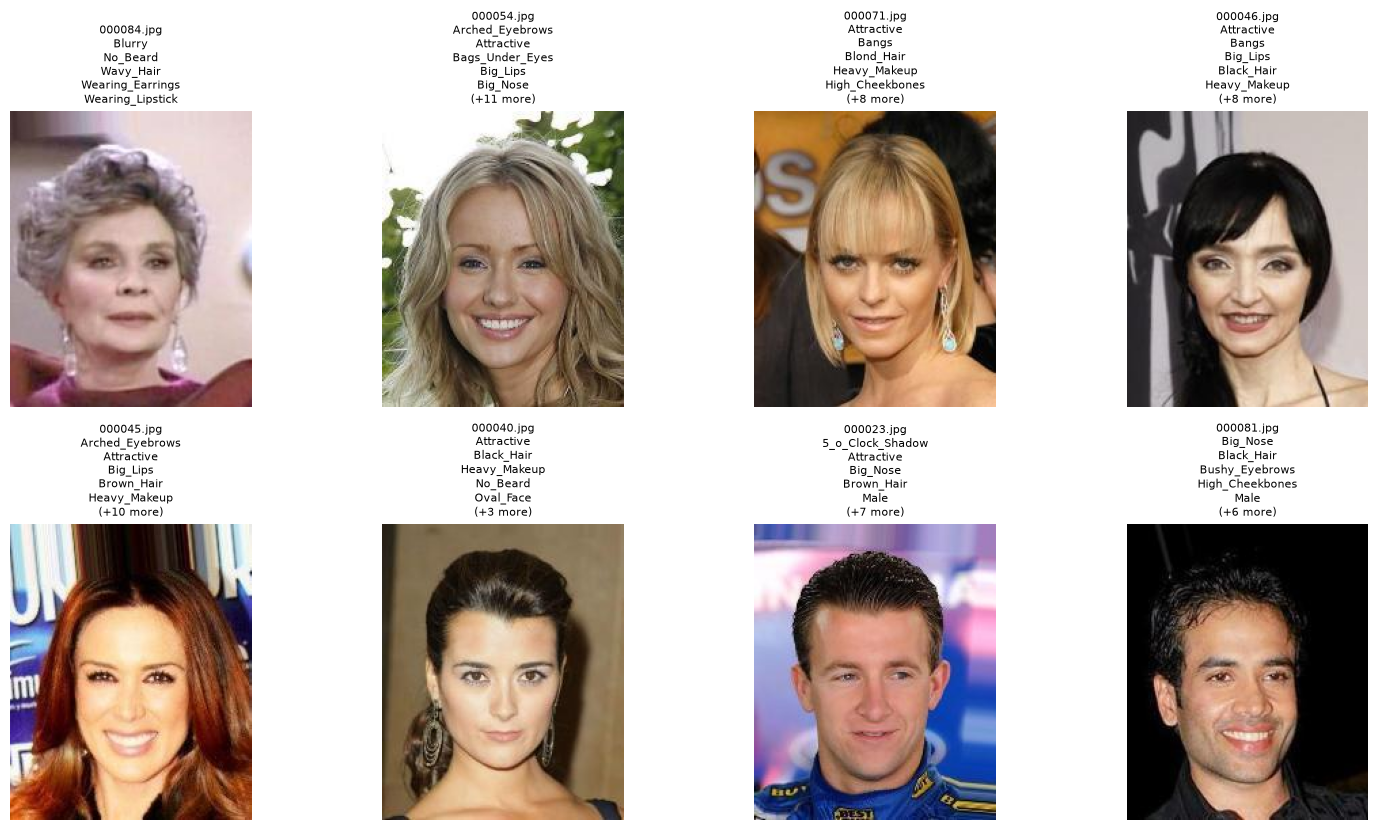

In [27]:
# Sample faces with their active positive attributes
fig_sample_attrs = plot_sample_attributes(
    df_attributes.head(100),
    align_img_dir,
    n_images=8,
    random_state=42,
    max_attrs_to_show=5,
)
plt.show()

## 6. Base EDA Module Verification (`modules.vision.eda.base`)
Calling `run_eda` to verify interface compliance.

In [29]:
from modules.vision.eda.base import run_eda

run_eda("vision")
print("Base EDA module executed successfully.")

Base EDA module executed successfully.


# TODO
This is the TODO reminder to update the notebook and should not be in the final product.